*https://www.kaggle.com/datasets/prathamtripathi/drug-classification?resource=download*

## **Importing libraries and loading the dataset**

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import requests
import warnings
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
requests.packages.urllib3.disable_warnings()
warnings.filterwarnings("ignore")
%matplotlib inline

In [5]:
data = pd.read_csv("/content/drive/MyDrive/Python Projects/Drug Classification/drug200.csv")
data.to_csv("/content/drive/MyDrive/Python Projects/Drug Classification/drug200.csv",index = False)

In [6]:
data

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


## **Naïve Bayes**

In [21]:
# Assuming your data is loaded into a DataFrame named 'df'
df = pd.DataFrame({
    'Sex': ['F', 'M', 'M', 'F', 'F', 'M'],
    'BP': ['HIGH', 'LOW', 'LOW', 'NORMAL', 'LOW', 'NORMAL'],
    'Cholesterol': ['HIGH', 'HIGH', 'HIGH', 'HIGH', 'HIGH', 'NORMAL'],
    'Na_to_K': [25.355, 13.093, 10.114, 7.798, 18.043, 9.894],
    'Drug': ['DrugY', 'drugC', 'drugC', 'drugX', 'DrugY', 'drugX']
})


In [24]:
# Initialize LabelEncoders for each categorical column
label_encoder = LabelEncoder()

In [25]:
# Encode categorical columns
df['Sex'] = label_encoder.fit_transform(df['Sex'])
df['BP'] = label_encoder.fit_transform(df['BP'])
df['Cholesterol'] = label_encoder.fit_transform(df['Cholesterol'])
df['Drug'] = label_encoder.fit_transform(df['Drug'])

In [44]:
# Separate features (X) and target (y)
X = data.drop(columns=['Drug', 'Age'])  # Features
y = data['Drug']  # Target variable

# Perform the train-test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)

In [45]:
# Create the Gaussian Naive Bayes model
model = GaussianNB()

# Train the model
model.fit(X_train, y_train)

GaussianNB()

In [46]:
# Predict the output for the test set
y_pred = model.predict(X_test)

# Print the predictions
print("Predictions:", y_pred)

# Evaluate the model's accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Predictions: [1 0 3 0 0 0 0 3 3 3 1 1 1 0 3 1 3 4 1 3 2 4 0 2 0 2 4 1 4 0 4 4 4 4 1 1 3
 1 4 4]
Accuracy: 0.70


## **Visualization**

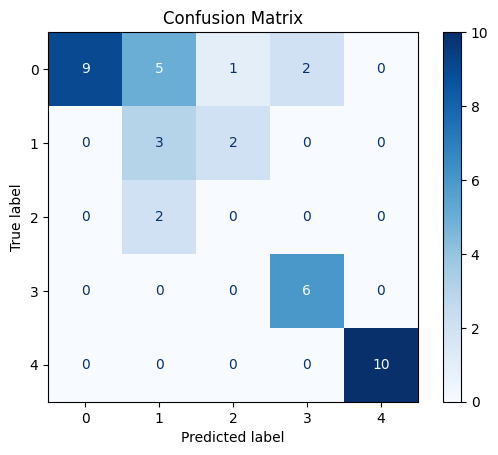

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
cm_display.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

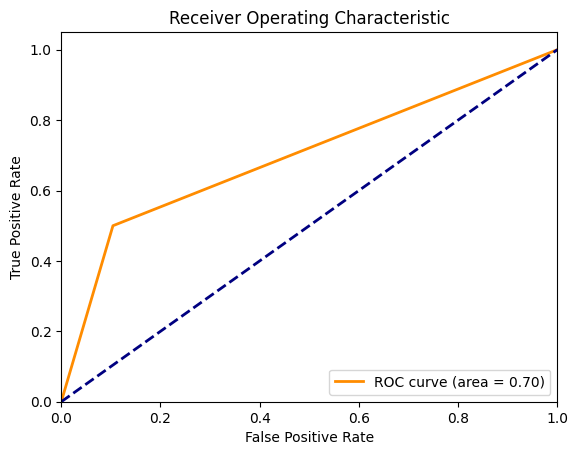

In [48]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the output (required for multiclass ROC)
y_bin = label_binarize(y_test, classes=[0, 1, 2])  # Update classes based on your encoded values
y_pred_bin = label_binarize(y_pred, classes=[0, 1, 2])

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_bin.ravel(), y_pred_bin.ravel())
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


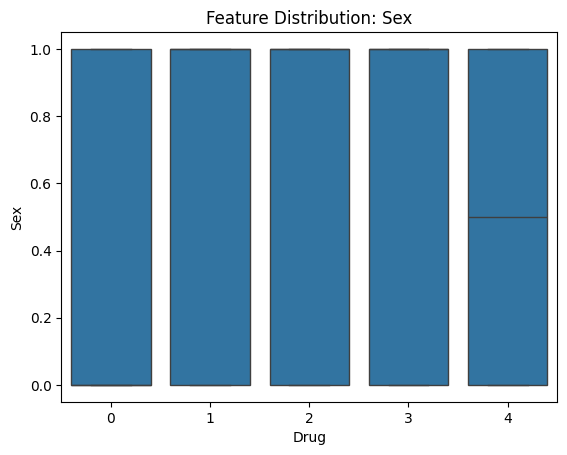

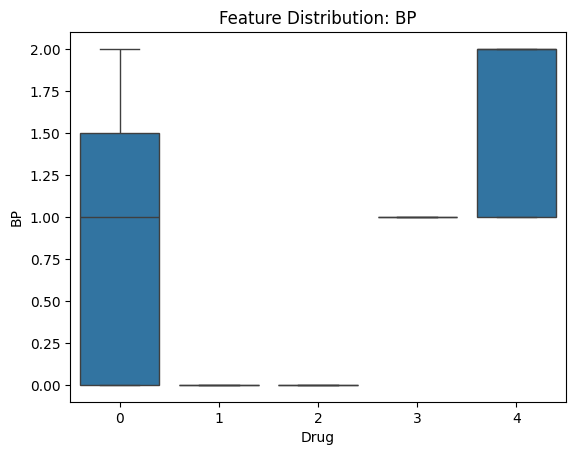

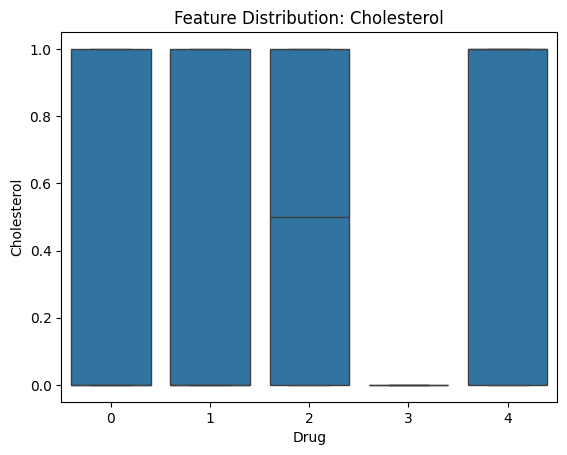

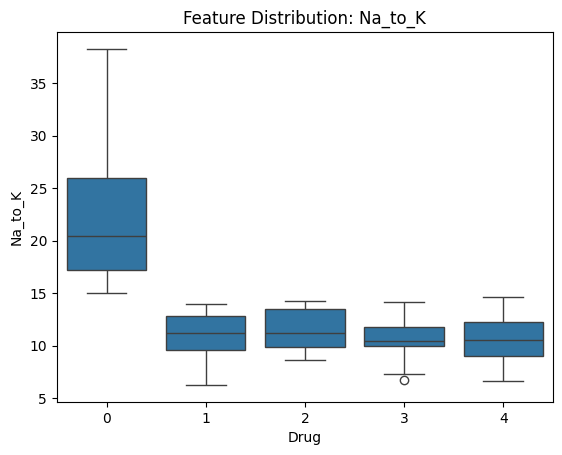

In [49]:
# Visualize the feature distributions for each class
for feature in X.columns:
    sns.boxplot(x=y, y=data[feature], data=data)
    plt.title(f'Feature Distribution: {feature}')
    plt.show()